## BBM 409 - Programming Assignment 1

* You can add as many cells as you want in-between each question.
* Please add comments to your code to explain your work.  
* Please add Markdown cells to answer the (non-coding) questions in the homework text. You can, however, refer to the outputs of code cells without adding them as images to the Markdown cell unless you are requested to do otherwise.
* Please be careful about the order of runs of cells. Doing the homework, it is likely that you will be running the cells in different orders, however, they will be evaluated in the order they appear. Hence, please try running the cells in this order before submission to make sure they work.    
* Please refer to the homework text for any implementation detail. Though you are somewhat expected to abide by the comments in the below cells, they are mainly just provided for guidance. That is, as long as you are not completely off this structure and your work pattern is understandable and traceable, it is fine. For instance, you do not have to implement a particular function within a cell just because the comment directs you to do so.
* This document is also your report. Show your work.

###  Mustafa Emir Tezcan - 2230356092

## Understanding Perceptron Learning Algorithm (100 points)

### 1. Data Loading and Exploration (5 points)
* Brief overview of the task.

In this assignment, the Perceptron Learning Algorithm will be implemented to perform binary classification on the Raisin Dataset from the UCI Machine Learning Repository. The dataset, which consists of 900 samples, will be classified into the 'Kecimen' and 'Besni' classes.
The project is structured into the following parts:

   1. Implementing the Perceptron Learning Algorithm from scratch.
   2. Evaluating the performance of the Perceptron on the Raisin Dataset.
   3. Visualizing the decision boundary (or hyperplane) formed by the Perceptron.
   4. Exploring Fisher’s Linear Discriminant for dimensionality reduction and visualization.

* Description of the dataset used for analysis.

The analyzed Raisin dataset contains 900 samples, each defined by 7 numerical features (e.g., Area, MajorAxisLength). The target variable, Class, is binary and perfectly balanced, with 450 samples each for the 'Besni' and 'Kecimen' categories. An assessment of data quality confirms the dataset is clean, containing no missing values in either the features or the target variable.
 Summary statistics show significant discrepancies in the scales of the features (e.g., Area mean 87,804 vs. Eccentricity mean 0.78), highlighting that feature scaling will be an essential preprocessing step before machine learning modeling.



In [1]:
## Import necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

In [2]:
## Read the regression data
from ucimlrepo import fetch_ucirepo

# fetch dataset
raisin = fetch_ucirepo(id=850)

# data (as pandas dataframes)
X = raisin.data.features
y = raisin.data.targets

# metadata
print(raisin.metadata)

# variable information
print(raisin.variables)

{'uci_id': 850, 'name': 'Raisin', 'repository_url': 'https://archive.ics.uci.edu/dataset/850/raisin', 'data_url': 'https://archive.ics.uci.edu/static/public/850/data.csv', 'abstract': 'Images of the Kecimen and Besni raisin varieties were obtained with CVS. A total of 900 raisins were used, including 450 from both varieties, and 7 morphological features were extracted.', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 900, 'num_features': 7, 'feature_types': ['Real', 'Integer'], 'demographics': [], 'target_col': ['Class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2020, 'last_updated': 'Fri Jan 05 2024', 'dataset_doi': '10.24432/C5660T', 'creators': ['İ̇lkay Çinar', 'Murat Koklu', 'Sakir Tasdemir'], 'intro_paper': {'ID': 261, 'type': 'NATIVE', 'title': 'Kuru Üzüm Tanelerinin Makine Görüşü ve Yapay Zeka Yöntemleri Kullanılarak Sınıflandırılması', 'authors': 'İ̇lkay Çinar

In [3]:
# Display the first few rows of the dataset
print("\nFirst few rows of the dataset:")
print(X.head())


First few rows of the dataset:
    Area  MajorAxisLength  MinorAxisLength  Eccentricity  ConvexArea  \
0  87524       442.246011       253.291155      0.819738       90546   
1  75166       406.690687       243.032436      0.801805       78789   
2  90856       442.267048       266.328318      0.798354       93717   
3  45928       286.540559       208.760042      0.684989       47336   
4  79408       352.190770       290.827533      0.564011       81463   

     Extent  Perimeter  
0  0.758651   1184.040  
1  0.684130   1121.786  
2  0.637613   1208.575  
3  0.699599    844.162  
4  0.792772   1073.251  


In [4]:
## Explore the dataset (e.g., size, features, target variables, summary statistics).
## Check for any missing values and handle them if necessary.

# Dataset size, features, and target variable information
print("Dataset size (rows, columns):", X.shape) #
print("\nNumber of features:", X.shape[1])
print("Feature names:", X.columns.tolist())
print("Number of classes in target variable:", y.nunique())
print("Target variable distribution:\n", y.value_counts())
print(y)

# Summary statistics
print("\nSummary statistics:")
print("\nSummary statistics of features:\n",X.describe())
print("\nSummary statistics of target variable:\n",y.describe())


# Check for missing values
missing_values_features = X.isnull().sum()
print("\nMissing values in features:\n", missing_values_features)
missing_values_target = y.isnull().sum()
print("\nMissing values in target variable:\n", missing_values_target)

# Handle missing values if the target variable ( drop rows with missing target values)
if missing_values_target.any():
    y = y.dropna()
# Handle missing values in features (imputation with mean)
if missing_values_features.any():
    X = X.fillna(X.mean())

Dataset size (rows, columns): (900, 7)

Number of features: 7
Feature names: ['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'ConvexArea', 'Extent', 'Perimeter']
Number of classes in target variable: Class    2
dtype: int64
Target variable distribution:
 Class  
Besni      450
Kecimen    450
Name: count, dtype: int64
       Class
0    Kecimen
1    Kecimen
2    Kecimen
3    Kecimen
4    Kecimen
..       ...
895    Besni
896    Besni
897    Besni
898    Besni
899    Besni

[900 rows x 1 columns]

Summary statistics:

Summary statistics of features:
                 Area  MajorAxisLength  MinorAxisLength  Eccentricity  \
count     900.000000       900.000000       900.000000    900.000000   
mean    87804.127778       430.929950       254.488133      0.781542   
std     39002.111390       116.035121        49.988902      0.090318   
min     25387.000000       225.629541       143.710872      0.348730   
25%     59348.000000       345.442898       219.111126      0.741766   

In [5]:
# Convert the DataFrame to a Numpy array
X_array= X.to_numpy()
y = y.squeeze()
y = y.map({'Kecimen': 1, 'Besni': -1}) # Map target variable to binary values (Class 1 and Class 0)
y_array = y.to_numpy()

### 2. Data Preprocessing (5 points)

#### 2.1 Training and Validation Split
* 1. Explain why it’s important to use the validation set to evaluate your model instead of relying solely on the training data.

Relying solely on training data to evaluate a model is misleading because it measures memorization, not learning. A model can sometimes overfit the training data. Overfitting happens when the model learns the small details and noise in the training data instead of the general patterns that apply more broadly. Consequently, the model may achieve exceptionally high accuracy on the training data, giving a false impression of success. However, when this overfit model is exposed to new, unseen data, its performance will be poor because it has failed to learn the generalizable features and instead memorized specific examples.

* 2. Discuss how evaluating the model on unseen data helps in assessing its generalization capability.

Generalization is arguably the most critical objective in machine learning. It refers to a model's ability to adapt and perform accurately on new, previously unseen data that is drawn from the same distribution as the training data. The performance on unseen data is the true measure of a model's utility and effectiveness. It confirms whether the model is a robust, general-purpose tool or merely a brittle system that has memorized its training inputs.

In [6]:
# Split the dataset into training and testing sets (80% train, 20% test).
# The number 42 is arbitrary. It’s just a common convention in the data science community.
X_train, X_test, y_train, y_test = train_test_split(X_array, y_array, test_size=0.2, random_state=42, stratify=y)
# Print the shapes of the resulting sets.
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of Y_train:", y_train.shape)
print("Shape of Y_test:", y_test.shape)

Shape of X_train: (720, 7)
Shape of X_test: (180, 7)
Shape of Y_train: (720,)
Shape of Y_test: (180,)


#### 2.2 Feature Scaling
Feature scaling is important for many machine learning algorithms, especially those based on distance metrics (e.g., k-nearest neighbors, support vector machines) and gradient descent optimization (e.g., linear regression, logistic regression).Without appropriate scaling, features with large numerical ranges can dominate the model, leading to biased learning and unstable convergence

Some common feature scaling techniques include:

1. **Standardization (Z-score normalization):** It scales the features to have a mean of 0 and a standard deviation of 1.
2. **Min-Max Scaling:** It scales the features to a fixed range, typically between 0 and 1.
3. **Robust Scaling:** It scales the features based on percentiles, making it robust to outliers.

In this assignment, the dataset used for classification contains 900 samples and 7 numerical features, representing geometric measurements of two grape varieties: Besni and Kecimen. The selected features include Area, MajorAxisLength, MinorAxisLength, Eccentricity, ConvexArea, Perimeter, and Extent. Due to the nature of these measurements, the dataset exhibits heterogeneous feature scales and the presence of outliers, making the choice of scaling method particularly important for stable model performance.
##### Dataset Characteristics:
A summary of the dataset’s statistical properties highlights several key issues.

This is evidenced by two key observations:
#### 1. Mean vs. Median Discrepancy:
For several features, the mean is significantly larger than the median (the 50th percentile).
* Area: Mean ($\approx 87,804$) > Median ($78,902$)
* ConvexArea: Mean ($\approx 91,186$) > Median ($81,651$)
* Perimeter: Mean ($\approx 1,165$) > Median ($1,119$)

This discrepancy indicates a right-skewed distribution, where a small number of extremely large values are pulling the mean higher, away from the central tendency represented by the median.
#### 2. 75th Percentile vs. Maximum Value:
The 75th percentile (also known as the third quartile, Q3) represents the value below which approximately 75% of the observations in the dataset fall. In other words, it marks the upper boundary of the “typical” data range, while the remaining top 25% of values lie above this point. The gap between the 75th percentile and the maximum value is disproportionately large.
* Area: 75% is $\approx 105,028$, while the max is $235,047$ (more than double).
* MajorAxisLength: 75% is $\approx 494$, while the max is $997$ (more than double).
* Perimeter: 75% is $\approx 1,308$, while the max is $2,697$ (more than double).

This shows that while 75% of the data is relatively contained, the top 25% includes extreme outliers that dramatically extend the feature's range.

Based on the statistical analysis of the dataset, Robust Scaling is the  suitable feature scaling technique. The data demonstrates clear signs of right-skewed distributions and the presence of extreme outliers. Specifically, for several features such as Area, ConvexArea, and Perimeter, the mean is notably greater than the median, indicating that a small number of very large values are pulling the average upward. Additionally, the gap between the 75th percentile and the maximum value is disproportionately large, showing that while most of the data (the lower 75%) is contained within a moderate range, the top 25% includes extremely high observations that extend the feature range significantly.

Other scaling methods like StandardScaler or MinMaxScaler rely on the mean, standard deviation, minimum, and maximum values, which are all highly sensitive to outliers. Using these methods on this dataset would result in distorted feature distributions, causing the majority of the data points to be compressed into narrow ranges and reducing the effectiveness of the model.

In contrast, RobustScaler scales features using the median and the interquartile range (IQR), which are robust statistics that are not influenced by extreme values. This ensures that the scaling process reflects the central tendency of the majority of the data while minimizing the impact of outliers. As a result, features such as Area and ConvexArea, which contain extremely large observations are normalized without affecting the overall distribution pattern.

In [7]:
## Analyze the dataset and decide whether scaling is needed.
## Explain your choices in a brief comment.
scaler = RobustScaler()

# Fit and transform the training data, and transform the test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert the scaled data back to DataFrame for better readability
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

### 3. Implementing Perceptron for Binary Classification (20 points)

* Explain the reason behind the application of perceptron learning algorithm on this type of data. If the dataset had two classes but was not linearly separable, how would the perceptron's performance change? Briefly explain.

The Perceptron learning algorithm is applied to this dataset because it is a binary classification problem involving two distinct classes, Besni and Kecimen.The Perceptron, being a linear classifier, attempts to find a single hyperplane that separates these two classes based on their feature values.The algorithm works effectively when the data is linearly separable, meaning that there exists at least one straight line (in two dimensions) or hyperplane (in higher dimensions) that can perfectly divide the two classes. In such cases, the Perceptron is guaranteed to converge to a solution within a finite number of iterations, resulting in accurate classification performance. However, if the data is not linearly separable, the Perceptron cannot find a perfect decision boundary and therefore fails to converge. In this case, the algorithm continues to update its weights indefinitely or oscillates without improvement. Consequently, its performance decreases, and the resulting model may misclassify several samples.

####  Implement Percepton Learning Algorithm

 The use of basic libraries like Matlab, pandas, and numpy is allowed, but the use of ready-to-use libraries such as scikit-learn is prohibited

In [8]:
class Perceptron:
    def __init__(self, learning_rate=0.05, n_epochs=2000, random_state=None, shuffle=True):
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.random_state = random_state
        self.shuffle = shuffle
        self.weights = None
        self.bias = None
        self.errors_per_epoch = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features) # Initial weights
        self.bias = 0 # Initial value of bias

        if self.random_state:
            np.random.seed(self.random_state)

        for _ in range(self.n_epochs):
            errors = 0 # Count of misclassifications in each epoch
            if self.shuffle:
                indices = np.arange(n_samples)
                np.random.shuffle(indices) # Shuffle the data
                X = X[indices]
                y = y[indices]
            for idx, x_i in enumerate(X):
                z = np.dot(x_i, self.weights) + self.bias # prediction function
                y_predicted = 1 if z >= 0 else -1 # activation function
                if y_predicted != y[idx]:
                    self.weights += self.learning_rate * y[idx] * x_i # weight update rule
                    self.bias += self.learning_rate * y[idx] # bias update rule
                    errors += 1
            self.errors_per_epoch.append(errors)

    def predict(self, X):
        z = np.dot(X, self.weights) + self.bias # prediction function
        y_predicted = np.where(z >= 0, 1, -1) # activation function
        return y_predicted

* Explain each parameter used in your perceptron model (for example: weights, bias, learning rate, random_state, shuffle, etc.).
For each parameter, describe in detail its role in the model’s learning process and explain why it is important.

**Weights:** A vector of values corresponding to each input feature. These are the core parameters learned by the perceptron. They define the slope and orientation of the decision boundary separating the classes. Adjusting the weights during training allows the perceptron to learn from the data and improve its classification accuracy.

**Bias:** A constant term added to the weighted sum before applying the activation function. Shifts the decision boundary so that it doesn’t always have to pass through the origin. This flexibility is crucial for accurately classifying data that is not centered around the origin.

**Learning Rate:** Specifies the step size by which the weights and bias are updated during each learning iteration. After each misclassification, the perceptron adjusts its weights and bias to reduce future errors. The learning_rate determines how big that adjustment will be. A small learning rate may lead to slow convergence, while a large learning rate can cause overshooting and instability.

**Number of Epochs (n_epochs):** The number of times the entire training dataset is passed through the algorithm. Each epoch allows the model to repeatedly adjust the weights, improving accuracy over time. A higher number of epochs increases the chances of convergence but also increases computation time.

**Random State:** A seed value that controls the randomness used in data shuffling. It ensures the random processes (like data shuffling) are reproducible, meaning you get the same results every time you run the code. This is important for debugging and comparing model performance across different runs (The number 42 is arbitrary. It’s just a common convention in the data science community.).

**Shuffle:** A boolean value (True/False) that determines whether to shuffle the training data at the start of each epoch. Shuffling the data prevents the model from learning patterns based on the order of the samples, which could lead to bias. When shuffle is set to True, the data is randomly reordered before each epoch, promoting better generalization.

**Errors per Epoch:** A list storing the number of misclassified samples after each epoch. Used to track the model’s performance and visualize how the error decreases over time. It helps to evaluate convergence.

##### * Make sure you have defined all the necessary parameters in your perceptron model to optimize its performance.

* Discuss how the choice of learning rate and the number of epochs might affect the
training process. What happens with a very small or very large learning rate?

The learning rate and the number of epochs are two important factors that affect how the perceptron model learns during training. The learning rate and the number of epochs directly affect how the perceptron learns. A small learning rate makes the weight updates very slow, so the model takes longer to learn and may not reach an optimal solution. A large learning rate, however, causes the weights to change too much at each step, which can make learning unstable or prevent the model from converging.The number of epochs determines how many times the entire dataset is used for training. If there are too few epochs, the model might not learn enough from the data. If there are too many epochs, the model might keep updating the weights even after it has already learned, which can lead to overfitting or oscillation. In short, choosing a balanced learning rate and an appropriate number of epochs helps the perceptron learn efficiently and converge smoothly.

In this assignment, a learning rate of 0.05 and 2000 epochs were generally preferred to ensure stable and effective learning.

#### Accuracy implementation

In [9]:
def accuracy(y_true, y_pred):
    correct_predictions = np.sum(y_true == y_pred)
    total_predictions = len(y_true)
    return correct_predictions / total_predictions

#### Train the Perceptron

In [10]:
## Train the Perceptron model on the training set. You will use all features in the first classification.
perceptron = Perceptron(learning_rate=0.05, n_epochs=2000, random_state=42, shuffle=True) # It was previously stated why the random state is 42.
perceptron.fit(X_train_scaled, y_train)

#### Prediction on Training Data

In [11]:
# Predicting on the training data
y_pred_train = perceptron.predict(X_train_scaled)
accuracy_train = accuracy(y_train.flatten(), y_pred_train)
print("Training Accuracy:", accuracy_train)

Training Accuracy: 0.8527777777777777


**Answer the Guiding Questions:**

1. What does accuracy tell us about the performance of the model?
2. Why is accuracy sometimes not enough, especially in cases where the data is imbalanced? Explain a scenario where a high accuracy might be misleading.
3. In what types of problems is precision more important than recall?
4. In what cases is recall more critical?
5. When is the F1 score a better measure than accuracy? What are the limitations of using F1 score alone?

1.
    Accuracy is the most intuitive metric. Accuracy measures the proportion of correctly classified samples out of all samples. It gives an overall idea of how often the model’s predictions are correct. A high accuracy means that the model is performing well in general, assuming that all classes are equally important and the dataset is balanced.
2.
    Accuracy becomes a misleading metric with imbalanced datasets. In such cases, a model might predict the majority class most of the time and still achieve high accuracy, even though it performs poorly on the minority class. For example, in a medical diagnosis dataset where 95% of patients are healthy and 5% have a disease, a model that always predicts “healthy” would have 95% accuracy but would completely fail to detect any actual patients with the disease.
3.
    Precision is more important when the cost of a False Positive is high. Because precision formulates the ratio of True Positives to the sum of True Positives and False Positives, it focuses on minimizing the number of incorrect positive predictions. For example, in hiring decisions, if a company wants to avoid hiring unqualified candidates, they would prioritize precision to ensure that those predicted as qualified are indeed qualified.

4.
    Recall is more critical when the cost of a False Negative is high. Since recall calculates the ratio of True Positives to the sum of True Positives and False Negatives, it emphasizes capturing as many actual positive cases as possible. For instance, in disease screening, it is crucial to identify all patients with the disease, even if it means some healthy individuals are incorrectly flagged for further testing.
5.
    The F1 score is a better measure than accuracy when dealing with imbalanced datasets or when both precision and recall are important. The F1 score is the harmonic mean of precision and recall, providing a single metric that balances both concerns. It is particularly useful when the positive class is rare, as it ensures that neither precision nor recall is neglected. However, the F1 score has limitations. It does not take into account True Negatives, which can be important in certain contexts. Additionally, it gives equal weight to precision and recall, which may not always align with the specific priorities of a given application. Therefore, it is often beneficial to consider multiple metrics alongside the F1 score for a comprehensive evaluation of model performance. F1 score is not intuitive like accuracy, making it harder to interpret for stakeholders unfamiliar with the metric.

### 4. Evaluating Perceptron for Binary Classification (25 points)

#### Prediction on Validation Data

In [12]:
## Evaluate the model's performance on the test set by calculating accuracy. Print classification report and confusion matrix
y_pred_test = perceptron.predict(X_test_scaled)
accuracy_test = accuracy(y_test.flatten(), y_pred_test)
print("Testing Accuracy:", accuracy_test)

Testing Accuracy: 0.8666666666666667


#### Calculating Metrics

In [13]:
def calculate_metrics(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == -1) & (y_pred == -1))
    fp = np.sum((y_true == -1) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == -1))

    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    return accuracy, precision, recall, f1

# Calculate and print metrics
accuracy_train, precision_train, recall_train, f1_train = calculate_metrics(y_train.flatten(), y_pred_train)

print(f"Training Accuracy: {accuracy_train}")
print(f"Training Precision: {precision_train}")
print(f"Training Recall: {recall_train}")
print(f"Training F1 Score: {f1_train}")

Training Accuracy: 0.8527777777777777
Training Precision: 0.8802395209580839
Training Recall: 0.8166666666666667
Training F1 Score: 0.8472622478386167


 *Carefully examine the **classification report** obtained after the classification process.  
Analyze each metric in the report — such as **accuracy, precision, recall, f1-score, and support** — and interpret the performance of your model.*  

*For each metric, explain:*  
*- What this value represents in the context of your model,*  
*- What it means if the value is high or low, and*  
*- Which aspects of your model are strong or weak based on this metric.*


**Accuracy** is the percentage of all predictions that the model got right on the training dataset. An accuracy of 85.3% means that out of all the samples in the test set, the model correctly classified about 85 out of every 100 samples. A high value (near 1.0) is good, showing high overall correctness. A low value (near 0.5 for a balanced dataset) would be poor. At 85.3%, this is a strong score. It indicates that the model's predictions are correct the vast majority of the time on the data it was trained on.

**Precision** answers the question: "Of all the times the model predicted the 'Kecimen' (Positive) class, what percentage was correct?" It measures the quality or purity of the positive predictions. A high value is good. It means the model has a low False Positive rate.A low value means that when the model predicts "Positive," it's wrong a significant portion of the time. At 88.0%, this is a strong precision score, indicating that when the model predicts 'Kecimen,' it is correct 88% of the time. This suggests that the model is effective at avoiding false alarms.

**Recall** answers the question: "Of all the actual 'Positive' cases in the data, what percentage did the model successfully find?" It measures the model's completeness or sensitivity.
A high value means the model has a low False Negative rate (finds most positive cases). A low value means the model "misses" many true positive cases. At 81.7%, this score is good, but it's the weakest link among the metrics. It indicates the model missed 18.3% of the actual positive cases in the training data. This is a weakness if the cost of a False Negative is high.

**F1 Score** is the harmonic mean of Precision and Recall. It provides a single number that balances both concerns. It's especially useful when you have an imbalanced dataset or when the costs of False Positives and False Negatives are both important. A high value (near 1.0) indicates a good balance of high precision and high recall. A low value indicates the model is failing at one or both. 84.7% is a solid, well-balanced score. It confirms that the model is performing well overall. It is slightly lower than the Accuracy and Precision scores because it is pulled down by the relatively weaker Recall score. This score summarizes the model's trade-off: it sacrifices a bit of completeness (Recall) to achieve high reliability (Precision).

### 5. Visualization of the Hyperplane (40 + 5 points)

In this section, you will explore how the Perceptron Learning Algorithm forms the decision boundary (or hyperplane) that separates the two classes. To be able to do that
you will reduce the feature space to two dimensions, train the Perceptron on the selected
features, and visualize the hyperplane. The goal is to understand how the Perceptron
changes the decision boundary as the data changes, and how it adapts based on the
features used.

#### Step 1: Feature Selection Using Correlation Analysis (10 points)

1. Correlation Analysis: One effective way to reduce the number of features is by
analyzing the correlation between them. Highly correlated features may provide re-
dundant information, so you can select two less correlated features for visualization.
2. Compute the correlation matrix: Analyze the relationship between the all features to identify pairs of features with low
correlation.

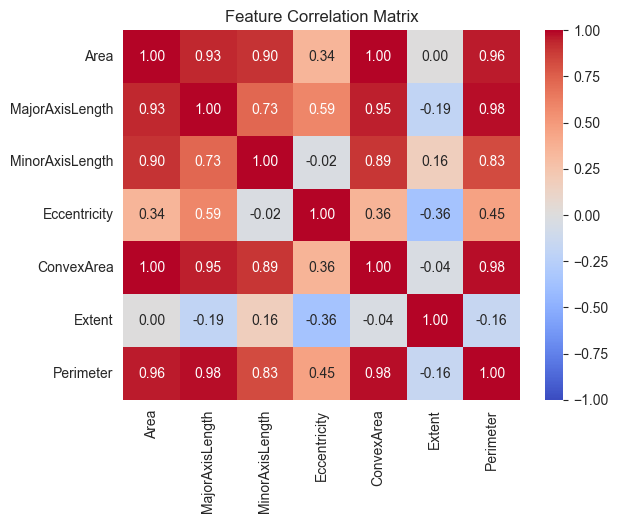

In [14]:
# Compute the correlation matrix
correlation_matrix = X_train_scaled_df.corr()

# Display the correlation matrix as a heatmap with scale between -1 and 1
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix")
plt.show()

3. Choose two features: Based on the correlation analysis, select two features that are
least correlated (e.g., variance and skewness) to visualize the Perceptron’s decision
boundary.
Based on the  analysis of the correlation matrix:
- **Lowest Correlation Pair:** 'Extent' and 'Area' with a correlation of approximately 0.00.

This pair is ideal for visualizing the Perceptron's decision boundary, as the features provide independent information, which should result in a clearer separation.



In [15]:
X_lowest_correlation = X_train_scaled_df[['Extent', 'Area']].to_numpy()
X_train_low_cor, X_test_low_cor, y_train_low_cor, y_test_low_cor = train_test_split(X_lowest_correlation, y_train, test_size=0.2, random_state=42, stratify=y_train)

#### Step 2: Train the Perceptron on Selected Features (10 points)

1. Retrain the Perceptron: After selecting two features, train the Perceptron using
only these two features. Use the same training and evaluation process as before,
but now the model will work in a two-dimensional feature space.

In [16]:
## Train the Perceptron model on the training set.
perceptron_lowest_correlation = Perceptron(learning_rate=0.05, n_epochs=2000, random_state=42, shuffle=True)
perceptron_lowest_correlation.fit(X_train_low_cor, y_train_low_cor)
# Predicting on the training data
y_pred_train_low_cor = perceptron_lowest_correlation.predict(X_train_low_cor)
accuracy_train = accuracy(y_train_low_cor, y_pred_train_low_cor)
print("Training Accuracy:", accuracy_train)

Training Accuracy: 0.7951388888888888


2. Visualize the decision boundary (hyperplane): Once the Perceptron is trained, plot
the decision boundary (hyperplane) to see how the Perceptron separates the two
classes in 2D.

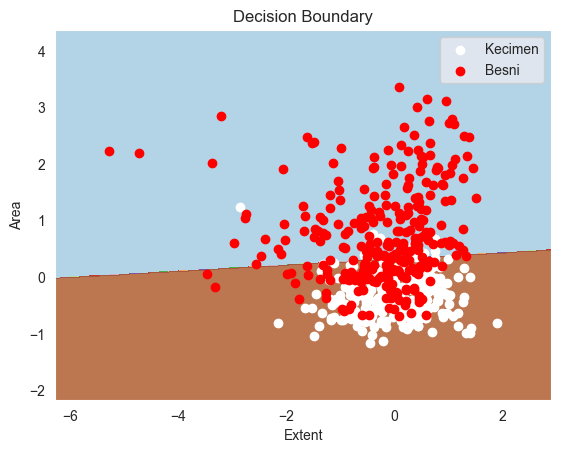

In [17]:
# Function to plot the decision boundary
def plot_decision_boundary(X, y, model, feature_names):
    # Create a mesh grid for plotting
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    # Compute the decision boundary
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the decision boundary
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)

    # Plot the data points
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='white', label='Kecimen')
    plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], color='red', label='Besni')

    # Add labels and title
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title("Decision Boundary")
    plt.legend()
    plt.grid()
    plt.show()

# Plot the decision boundary using the selected features and trained model
plot_decision_boundary(X_train_low_cor, y_train_low_cor, perceptron_lowest_correlation, feature_names=['Extent', 'Area'])

#### Step 3: Experiment with Different Features (10 points)

After visualizing the decision boundary for one pair of features, try selecting different
combinations of features (e.g., Area and MaxorAxisLength) and retrain the Perceptron. Compare
how the hyperplane changes with different features. This helps in understanding how the
Perceptron’s decision-making process adapts to different feature sets.

In [18]:
# Select two features (for example (Area and ConvexArea) and two more pair) according to their correlation
# Select these features from the original feature set
# Find a pair of features such that the separation between classes is at its highest level. Similarly, find a pair of features such that the separation between classes is at its lowest level. Finally, find the pair of features with average separability.
# Split the selected features into training and validation sets if not done yet
X_high_separation = X_train_scaled_df[['Perimeter', 'MajorAxisLength']].to_numpy()
X_low_separation = X_train_scaled_df[['Extent','Eccentricity']].to_numpy()
X_avg_separation = X_train_scaled_df[['Area','ConvexArea']].to_numpy()

X_train_high, X_test_high, y_train_high, y_test_high = train_test_split(X_high_separation, y_train, test_size=0.2, random_state=42, stratify=y_train)
X_train_low, X_test_low, y_train_low, y_test_low = train_test_split(X_low_separation, y_train, test_size=0.2, random_state=42, stratify=y_train)
X_train_avg, X_test_avg, y_train_avg, y_test_avg = train_test_split(X_avg_separation, y_train, test_size=0.2, random_state=42, stratify=y_train)


Training Accuracy (High Separation Features): 0.828125


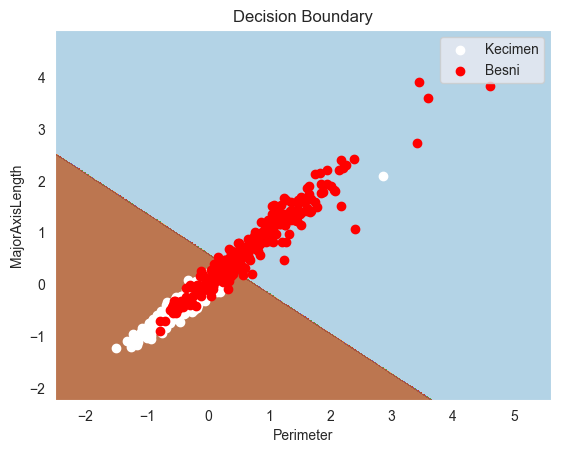

In [19]:
# Train and plot for high separation features
perceptron_high_separation = Perceptron(learning_rate=0.05, n_epochs=2000, random_state=42, shuffle=True)
perceptron_high_separation.fit(X_train_high, y_train_high)
# Predicting on the training data
y_pred_train_high = perceptron_high_separation.predict(X_train_high)
accuracy_train_high = accuracy(y_train_high.flatten(), y_pred_train_high)
print("Training Accuracy (High Separation Features):", accuracy_train_high)
# Plot the decision boundary using the selected features and trained model
plot_decision_boundary(X_train_high, y_train_high, perceptron_high_separation, feature_names=['Perimeter', 'MajorAxisLength'])

Training Accuracy (Low Separation Features): 0.7291666666666666


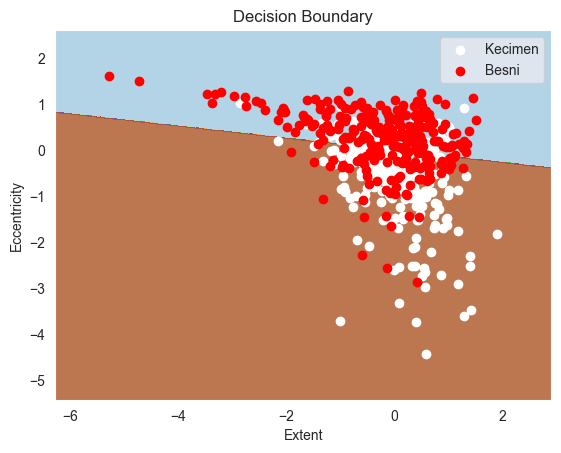

In [20]:
# Train and plot for low separation features
perceptron_low_separation = Perceptron(learning_rate=0.05, n_epochs=2000, random_state=42, shuffle=True)
perceptron_low_separation.fit(X_train_low, y_train_low)
# Predicting on the training data
y_pred_train_low = perceptron_low_separation.predict(X_train_low)
accuracy_train_low = accuracy(y_train_low.flatten(), y_pred_train_low)
print("Training Accuracy (Low Separation Features):", accuracy_train_low)
# Plot the decision boundary using the selected features and trained model
plot_decision_boundary(X_train_low, y_train_low, perceptron_low_separation, feature_names=['Extent', 'Eccentricity'])

Training Accuracy (Average Separation Features): 0.7638888888888888


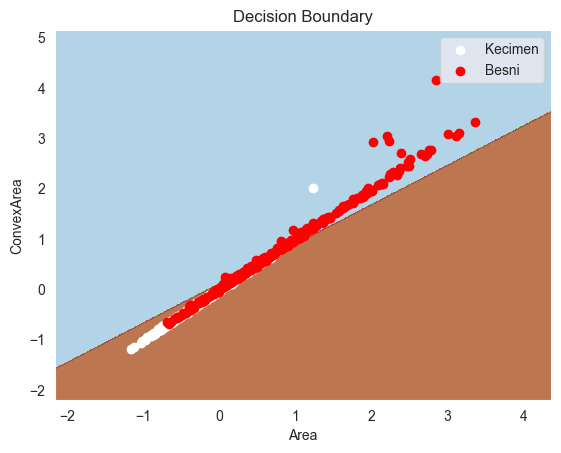

In [21]:
# Train and plot for average separation features
perceptron_avg_separation = Perceptron(learning_rate=0.05, n_epochs=2000, random_state=42, shuffle=True)
perceptron_avg_separation.fit(X_train_avg, y_train_avg)
# Predicting on the training data
y_pred_train_avg = perceptron_avg_separation.predict(X_train_avg)
accuracy_train_avg = accuracy(y_train_avg.flatten(), y_pred_train_avg)
print("Training Accuracy (Average Separation Features):", accuracy_train_avg)
# Plot the decision boundary using the selected features and trained model
plot_decision_boundary(X_train_avg, y_train_avg, perceptron_avg_separation, feature_names=['Area', 'ConvexArea'])

* Answer the guiding questions:  
1. How does the decision boundary change when you use different pairs of features?  
2. Can you find a pair of features that leads to better separation between the two classes? Also explain why this feature pair causes the better separation.
3. If the classes cannot be linearly separated in a given pair of features, can we still talk about a linear relationship between them? Explain your reasoning.


1. The choice of feature pairs has a significant impact on the resulting decision boundary. In our analysis, we examined three types of feature pairs with varying degrees of class separation:
    - **High Separation Features : Perimeter and MajorAxisLength (0.98 correlation)**
    - **Low Separation Features : Extent and Eccentricity (-0.36 correlation)**
    - **Average Separation Features : Area and ConvexArea (1.0 correlation)**

    For the high separation pair, data points from the two classes form well-defined clusters, allowing for a clear and nearly linear boundary. The average separation pair shows moderate overlap, resulting in a boundary that partially separates the classes but may misclassify some points. The low separation pair shows significant overlap between the classes, producing a less distinct boundary and higher potential for misclassification. The goodness of a decision boundary in classification does not directly depend on the correlation between features. Correlation (like 1.0 or -0.36) measures linear relationships between features themselves, not how well they separate different classes. However, features that are less correlated may provide more diverse information, which can sometimes help in better class separation. So the best features are usually lowly correlated but highly discriminative.

    This demonstrates that different feature pairs lead to changes in both the shape and effectiveness of the decision boundary, as they capture varying aspects of the data distribution.


2. Among the tested pairs, the high separation pair (Perimeter and MajorAxisLength) provides the best separation. The reason for this improved separability is that these features capture geometric characteristics that differ substantially between the two classes. Consequently, the clusters are more distinct, and the decision boundary can effectively discriminate between them.

    In contrast, features with lower separation tend to overlap more, making the boundary less effective. This illustrates that features should not only be lowly correlated but also highly discriminative to achieve good class separation.

3. Even when the classes cannot be linearly separated in a given feature pair (e.g., Extent and Eccentricity), it is still possible for a linear relationship to exist between the features themselves. Linear separability refers specifically to the ability to draw a straight line (or hyperplane) that separates the classes without error, whereas a linear relationship describes the correlation between two variables.

    For instance, two features may exhibit a linear trend, yet the class labels could be highly mixed in that feature space, making linear classification ineffective. Conversely, non-linear relationships might still allow partial or non-linear separation of classes.

    In the ConvexArea vs. Area feature pair, the points exhibit a linear distribution with high correlation (1.00), yet the classes cannot be linearly separated. This illustrates that a linear relationship between features does not imply linear separability of the classes.

    Therefore, linear separability and linear feature relationships are distinct concepts, each providing different insights for model selection.


#### Bonus Step 4: Incrementally Add Data (+ 5 points)

1. Visualizing Incremental Learning: Another experiment to help understand the behavior of the Perceptron is to add data incrementally. Start with a small portion of the dataset and progressively add more data points to train the Perceptron.

* For example, draw the decision boundary using the first 5% of the data, then increase it by 10% increments, continuing the process until the entire dataset is used, and draw the decision boundary at each step.


In [22]:
def incremental_learning_visualization(X, y, perceptron, feature_names, increments=10):
    n_samples = len(y)
    step_size = max(1, n_samples // increments)

    for i in range(1, increments + 1):
        # Select the first i * step_size samples
        subset_size = min(i * step_size, n_samples)
        X_subset = X[:subset_size]
        y_subset = y[:subset_size]

        # Train the Perceptron on the subset
        perceptron.fit(X_subset, y_subset)

        # Plot the decision boundary for the current subset
        print(f"Plot of decision boundary with {subset_size} samples:")
        plot_decision_boundary(X_subset, y_subset, perceptron, feature_names)

Plot of decision boundary with 57 samples:


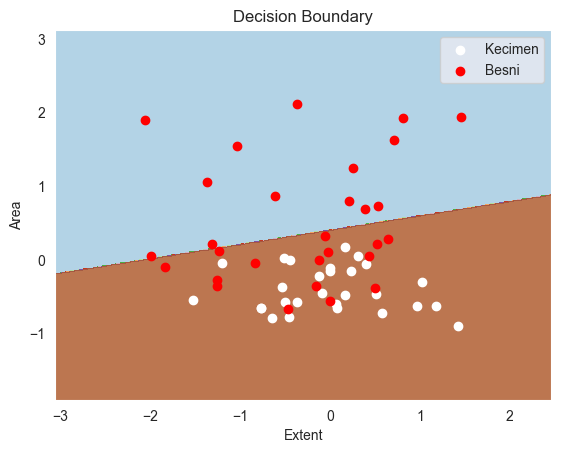

Plot of decision boundary with 114 samples:


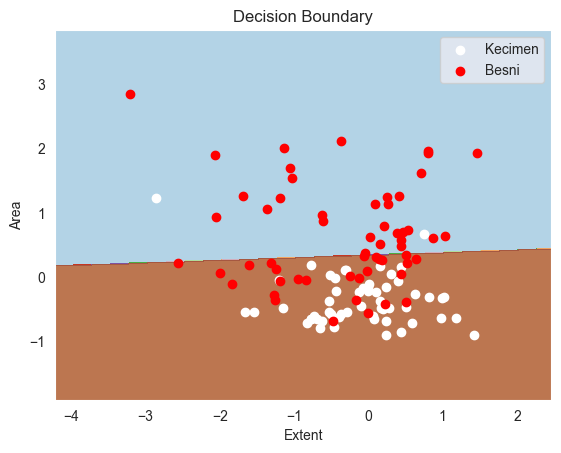

Plot of decision boundary with 171 samples:


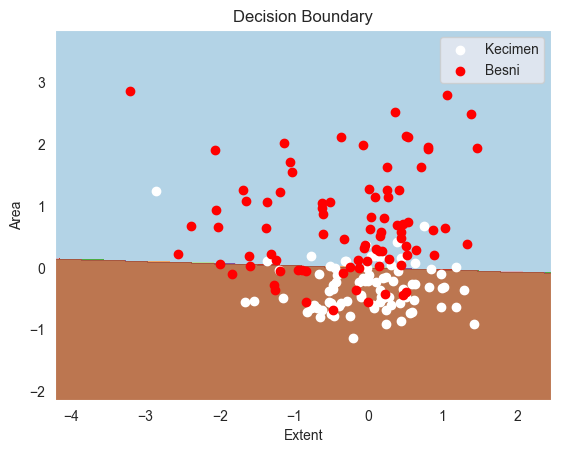

Plot of decision boundary with 228 samples:


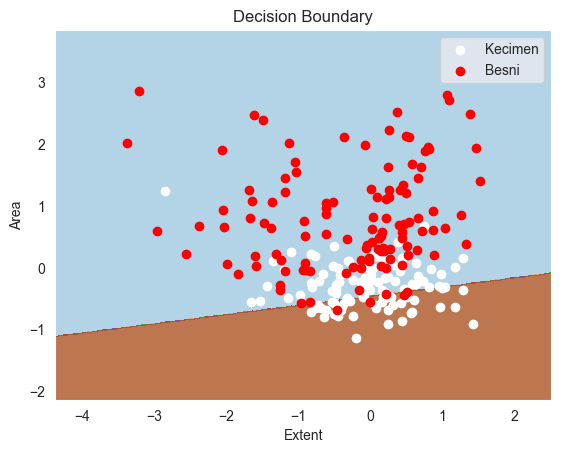

Plot of decision boundary with 285 samples:


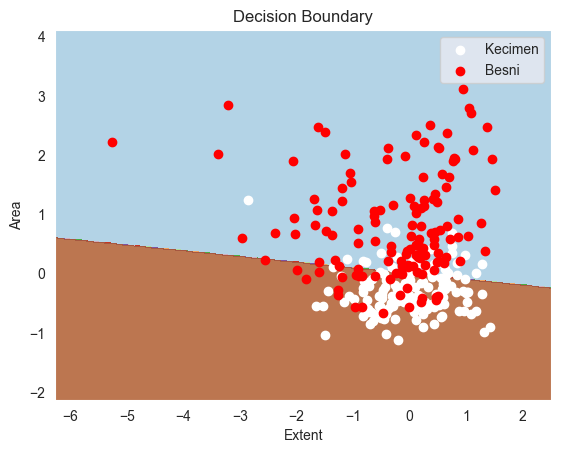

Plot of decision boundary with 342 samples:


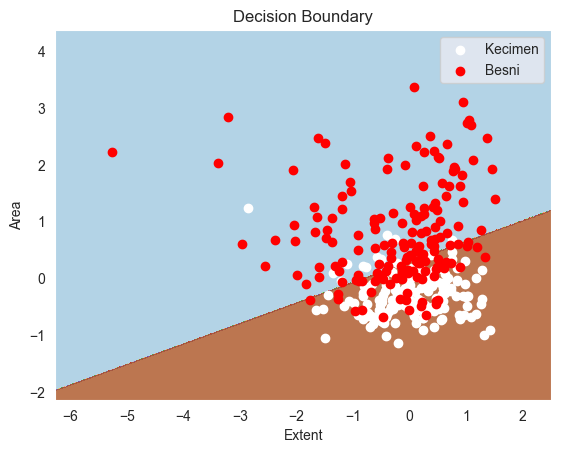

Plot of decision boundary with 399 samples:


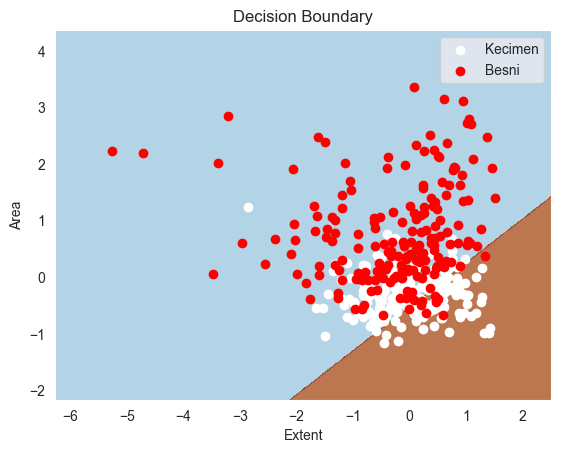

Plot of decision boundary with 456 samples:


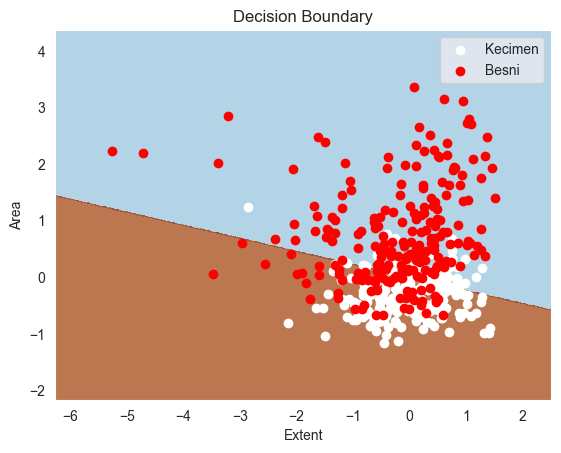

Plot of decision boundary with 513 samples:


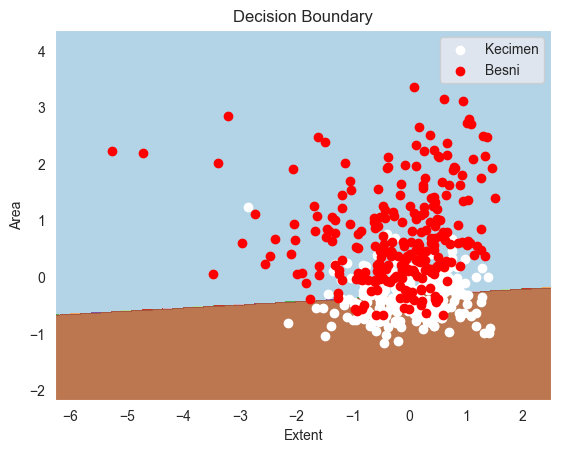

Plot of decision boundary with 570 samples:


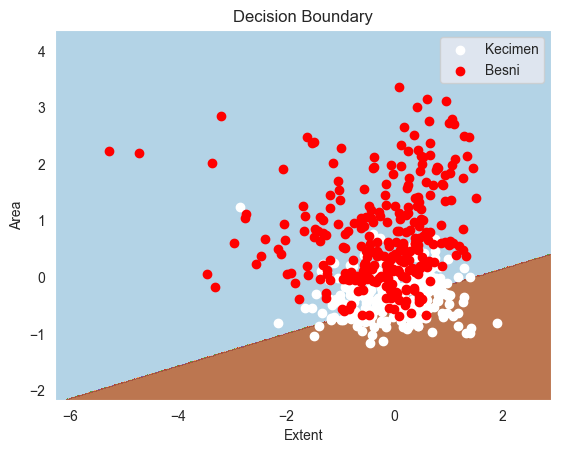

In [23]:
incremental_learning_visualization(X_train_low_cor, y_train_low_cor, perceptron_lowest_correlation, ['Extent', 'Area'], increments=10)

2. Observe how the decision boundary shifts: As you add more data, observe how the
hyperplane shifts and adapts to new points. This will help you understand how the
Perceptron continuously adjusts the boundary to separate the classes.

As more data points were added incrementally, the Perceptron’s decision boundary adjusted dynamically. Initially, with fewer points, the hyperplane was sensitive to outliers. As the dataset grew, the boundary shifted to better reflect the overall class distribution, becoming more stable and representative of the true separation.

#### Step 6: Fisher’s Linear Discriminant Projection (10 points)
* In this step, you will implement Fisher’s Linear Discriminant (LD) to project the
dataset onto a 1D space and visualize the distribution of the two classes in the projected
space using a histogram. The goal of Fisher’s LD is to find the direction in the feature
space that maximizes the separation between two classes while minimizing the variance
within each class. This technique projects the data onto a single dimension where the
separation between the classes is optimized.

In [24]:
def fisher_ld_projection(X, y):
    """Compute Fisher's Linear Discriminant projection direction."""

    # Separate the data into two classes
    class_0 = X[y == -1]
    class_1 = X[y == 1]

    # Compute the means of each class
    mean_0 = np.mean(class_0, axis=0)
    mean_1 = np.mean(class_1, axis=0)

    # Compute the within-class scatter matrix
    S_within_0 =np.dot((class_0-mean_0).T, (class_0-mean_0))
    S_within_1 =np.dot((class_1-mean_1).T, (class_1-mean_1))
    S_within = S_within_0 + S_within_1

    # Compute the inverse of the within-class scatter matrix
    S_within_inv = np.linalg.pinv(S_within)

    # Compute the Fisher LD projection direction
    w = np.dot(S_within_inv, (mean_1 - mean_0))

    # Normalize the projection direction
    w = w / np.linalg.norm(w)

    return w

def project_data(X, direction):
    """Project data onto the Fisher LD direction."""
    projected_data = np.dot(X, direction)
    return projected_data

In [25]:
direction = fisher_ld_projection(X_train_scaled, y_train)

# Project the data onto the Fisher LD direction
projected_data = project_data(X_train_scaled, direction)

### Visualizations
#### 2D Feature Space (Optional but Recommended)
* While not mandatory, it can be highly instructive to visualize the projection direction computed by Fisher’s LD in the original 2D feature space. This will help you understand how the data is being projected onto a 1D space and why this direction is optimal for class separation.

In [26]:
# Plot the 2D data with the projection direction

# Hint: You can use plt.scatter() to plot the 2D data with its features
# You can find the mean of the entire dataset for placing the direction vector
# Hint: You can use plt.quiver() method to visualize the direction vector
# Do not forget to scale the direction vector to visualize it properly
scale = 4 # Adjust this to control the length of the direction line

def plot_2d_with_projection(X,y,direction,scale):
    plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], color='blue', label='Class -1', alpha=0.7)
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='orange', label='Class 1', alpha=0.7)

    # Compute the mean of the dataset for placing the direction vector
    mean_point = np.mean(X, axis=0)

    # Plot the projection direction as a vector
    plt.quiver(mean_point[0], mean_point[1],
               direction[0] * scale, direction[1] * scale,
               angles='xy', scale_units='xy', scale=1, color='red', label='Projection Direction')

    plt.xlabel('Area')
    plt.ylabel('MajorAxisLength')
    plt.title('2D Feature Space with Fisher\'s LD Projection Direction')
    plt.legend()
    plt.grid()
    plt.show()

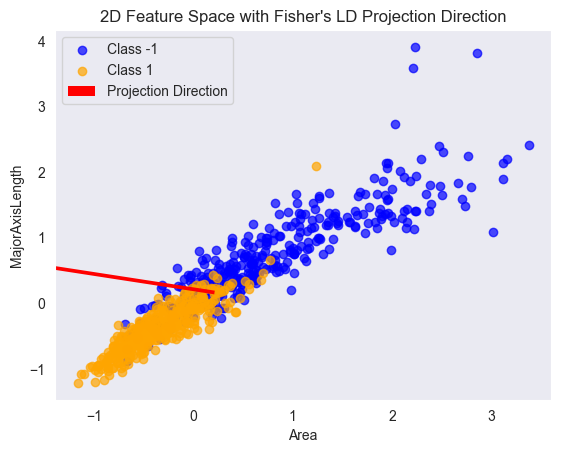

In [27]:
plot_2d_with_projection(X_train_scaled[:, :2], y_train, direction, scale)

### 1D Projected Space (Required)
* Plot a histogram showing the distribution of the
projected data for each class in the 1D space. The histogram will help you visualize
how well the two classes are separated by the Fisher’s LD projection.

In [28]:
# Plot the histogram of the projected data
def visualize_projected_data(projected_data, y):
    class_0 = projected_data[y == -1]
    class_1 = projected_data[y == 1]

    plt.hist(class_0, bins=20, alpha=0.7, label='Class -1', color='blue')
    plt.hist(class_1, bins=20, alpha=0.7, label='Class 1', color='orange')

    plt.xlabel('Projected Data')
    plt.ylabel('Frequency')
    plt.title('Histogram of Projected Data (Fisher\'s LD)')
    plt.legend()
    plt.grid()
    plt.show()

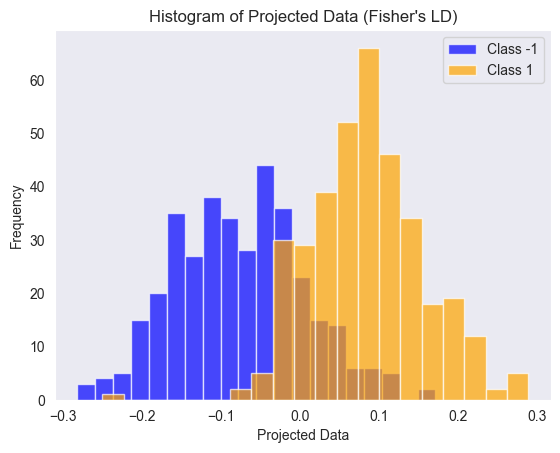

In [29]:
visualize_projected_data(projected_data, y_train)

Answer the guiding questions:
1. How well does Fisher’s LD separate the two classes in the 1D projected space?
2. Compare the separation of the two classes in the original 2D space (used in the
Perceptron) versus the 1D Fisher’s LD projection. What do you observe about the
class distributions in these spaces?

1.
Fisher’s Linear Discriminant (LD) is designed to find a projection that maximizes the separation between two classes. It does so by simultaneously maximizing the between-class variance, which pushes the means of the two classes as far apart as possible, and minimizing the within-class variance, which keeps the spread of points within each class compact. By optimizing this criterion, Fisher’s LD ensures that the projected 1D distributions of the classes are as distinct as possible.

   * Maximizes Between-Class Variance: Pushes the means of the two classes as far apart as possible.
   * Minimizes Within-Class Variance: Keeps the spread of points within each class compact.


   In the 1D projected space, Fisher’s LD produces well-separated class distributions, with minimal overlap, allowing for effective classification using a single threshold.
2.
    **Original 2D Space (Perceptron):**
    * Distribution: Classes are represented as 2D clusters, showing their shape and spread in both dimensions.
    * Separation: The Perceptron finds a linear decision boundary (a line) to separate the classes.
    * Observation: Classes may overlap or be perfectly separable depending on the data.

    **1D Fisher’s LD Projection:**
    * Distribution: The 2D space is projected onto a single line, reducing the classes to 1D distributions (histograms).
    * Separation: Fisher’s LD minimizes overlap in the 1D space, but some information is lost due to dimensionality reduction.
    * Observation: While the Perceptron can exploit the full 2D geometry to separate classes, projecting onto 1D via Fisher’s LD reduces dimensionality and may cause points that are distinct in 2D to overlap in 1D. However, the overall class separation is optimized along the projection direction.

